In [1]:
"""
Diffusion → Hilbert: Minimum signal experiment.

Question:
    Can a small ML learn a mapping from a compressed latent space
    (z ∈ R^8) to a 2-qubit Hilbert-space representation (ψ ∈ C^4),
    such that inner products between points are approximately preserved?

Design:
    1. Train a tiny autoencoder on MNIST → z ∈ R^8 per image.
    2. Define a principled target ψ ∈ C^4 via PCA-based angle encoding
       of z → 2 rotation angles → Ry(θ1)⊗Ry(θ2)|00⟩.
    3. Train three models (linear / MLP / structure-aware MLP) to map z → ψ.
    4. Measure MSE + inner-product preservation + distance preservation.

Author: (you)
Time box: 30 minutes on CPU.
"""

import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cpu


In [2]:
DATA_ROOT = "./data"

transform = transforms.Compose([transforms.ToTensor()])

# Use a subset for speed
train_ds = datasets.MNIST(DATA_ROOT, train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(DATA_ROOT, train=False, download=True, transform=transform)

N_TRAIN = 5000
N_TEST  = 1000

train_subset = Subset(train_ds, range(N_TRAIN))
test_subset  = Subset(test_ds,  range(N_TEST))

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_subset,  batch_size=128, shuffle=False, num_workers=2)

print(f"train: {len(train_subset)}  test: {len(test_subset)}")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:03<00:00, 2.58MB/s]
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 804kB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 2.17MB/s]
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 694kB/s]

train: 5000  test: 1000


In [3]:
LATENT_DIM = 8

class TinyAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 64), nn.ReLU(),
            nn.Linear(64, 32),  nn.ReLU(),
            nn.Linear(32, latent_dim),
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.ReLU(),
            nn.Linear(32, 64),         nn.ReLU(),
            nn.Linear(64, 784),        nn.Sigmoid(),
        )

    def encode(self, x):
        return self.enc(x)

    def forward(self, x):
        z = self.encode(x)
        return self.dec(z), z

ae = TinyAE().to(DEVICE)
print(f"AE parameters: {sum(p.numel() for p in ae.parameters()):,}")

AE parameters: 105,944


In [4]:
def train_ae(model, loader, epochs=5, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for x, _ in loader:
            x = x.to(DEVICE)
            x_hat, _ = model(x)
            loss = F.mse_loss(x_hat, x.view(x.size(0), -1))
            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * x.size(0)
        epoch_loss /= len(loader.dataset)
        losses.append(epoch_loss)
        print(f"  epoch {epoch+1}/{epochs}  loss={epoch_loss:.5f}")
    return losses

print("Training TinyAE...")
t0 = time.time()
ae_losses = train_ae(ae, train_loader, epochs=5)
print(f"done in {time.time()-t0:.1f}s")

Training TinyAE...
  epoch 1/5  loss=0.17354
  epoch 2/5  loss=0.07332
  epoch 3/5  loss=0.07012
  epoch 4/5  loss=0.06799
  epoch 5/5  loss=0.06512
done in 1.5s


In [5]:
@torch.no_grad()
def extract_latents(model, loader):
    model.eval()
    zs = []
    for x, _ in loader:
        x = x.to(DEVICE)
        z = model.encode(x)
        zs.append(z.cpu())
    return torch.cat(zs, dim=0)

z_train = extract_latents(ae, train_loader)
z_test  = extract_latents(ae, test_loader)

print(f"z_train: {z_train.shape}   z_test: {z_test.shape}")
print(f"z_train stats: mean={z_train.mean().item():.3f}  std={z_train.std().item():.3f}")

z_train: torch.Size([5000, 8])   z_test: torch.Size([1000, 8])
z_train stats: mean=-0.581  std=4.003


In [6]:
"""
Angle encoding:
    z ∈ R^8  →  PCA to 2D  →  scale to [0, π]  →  θ = (θ1, θ2)
    |ψ⟩ = Ry(θ1) ⊗ Ry(θ2) |00⟩
        = [cos(θ1/2)cos(θ2/2), cos(θ1/2)sin(θ2/2),
           sin(θ1/2)cos(θ2/2), sin(θ1/2)sin(θ2/2)]

This yields a 4-dimensional complex amplitude vector (real here),
normalized to ||ψ||=1.
"""

def fit_pca_2d(z):
    """Fit PCA on the training latents to get the top-2 directions."""
    z_centered = z - z.mean(dim=0, keepdim=True)
    # SVD on centered data
    U, S, V = torch.svd(z_centered)
    # top-2 principal directions (columns of V)
    components = V[:, :2]  # shape (8, 2)
    return components, z.mean(dim=0, keepdim=True)

def encode_to_psi(z, components, mean):
    """Map z ∈ R^N×8 to ψ ∈ R^N×4 via PCA + angle encoding."""
    z_centered = z - mean
    proj = z_centered @ components          # shape (N, 2)
    # normalize projection scale per-dimension
    std = proj.std(dim=0, keepdim=True) + 1e-6
    proj = proj / std
    # map to [0, π]
    # sigmoid keeps in (0,1) then * π gives (0, π)
    theta = torch.sigmoid(proj) * math.pi   # shape (N, 2)

    theta1 = theta[:, 0:1]                  # (N, 1)
    theta2 = theta[:, 1:2]

    c1 = torch.cos(theta1 / 2)
    s1 = torch.sin(theta1 / 2)
    c2 = torch.cos(theta2 / 2)
    s2 = torch.sin(theta2 / 2)

    psi = torch.cat([
        c1 * c2,   # amplitude of |00⟩
        c1 * s2,   # amplitude of |01⟩
        s1 * c2,   # amplitude of |10⟩
        s1 * s2,   # amplitude of |11⟩
    ], dim=1)                                   # shape (N, 4)

    # normalize (should already be ~1, but be safe)
    psi = psi / psi.norm(dim=1, keepdim=True)
    return psi

# Fit PCA on TRAINING latents only (avoid test leakage)
components, mean = fit_pca_2d(z_train)
print("components shape:", components.shape)

psi_train = encode_to_psi(z_train, components, mean)
psi_test  = encode_to_psi(z_test,  components, mean)

print(f"psi_train: {psi_train.shape}   psi_test: {psi_test.shape}")
print(f"norm check (should be ~1): {psi_train.norm(dim=1).mean().item():.6f}")
print(f"psi_train example: {psi_train[0].tolist()}")

components shape: torch.Size([8, 2])
psi_train: torch.Size([5000, 4])   psi_test: torch.Size([1000, 4])
norm check (should be ~1): 1.000000
psi_train example: [0.5465466380119324, 0.5140666961669922, 0.48154106736183167, 0.45292428135871887]


In [7]:
class LinearModel(nn.Module):
    def __init__(self, in_dim=8, out_dim=4):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim)

    def forward(self, z):
        psi = self.fc(z)
        return psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)


class TinyMLP(nn.Module):
    def __init__(self, in_dim=8, hidden=16, out_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, z):
        psi = self.net(z)
        return psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"Linear:  {count_params(LinearModel())} parameters")
print(f"TinyMLP: {count_params(TinyMLP())} parameters")

Linear:  36 parameters
TinyMLP: 212 parameters


In [8]:
def mse_loss(pred, target):
    return F.mse_loss(pred, target)


def inner_product_loss(pred, target):
    """Encourage that <psi_i, psi_j> matches the true one."""
    # Gram matrices
    G_pred = pred @ pred.T          # (N, N)
    G_true = target @ target.T      # (N, N)
    return F.mse_loss(G_pred, G_true)


def distance_loss(pred, target):
    """Encourage that ||psi_i - psi_j|| matches the true one."""
    d_pred = torch.cdist(pred, pred)     # (N, N)
    d_true = torch.cdist(target, target)
    return F.mse_loss(d_pred, d_true)

In [9]:
def train_model(model, z_train, psi_train, z_val, psi_val,
                epochs=200, lr=1e-3,
                w_mse=1.0, w_ip=0.0, w_dist=0.0,
                verbose=False):
    """Train with configurable loss weights."""
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    z_train = z_train.to(DEVICE)
    psi_train = psi_train.to(DEVICE)
    z_val = z_val.to(DEVICE)
    psi_val = psi_val.to(DEVICE)

    history = {"train": [], "val": []}

    for epoch in range(epochs):
        model.train()
        pred = model(z_train)
        loss = (w_mse * mse_loss(pred, psi_train)
                + w_ip * inner_product_loss(pred, psi_train)
                + w_dist * distance_loss(pred, psi_train))
        opt.zero_grad()
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            pred_val = model(z_val)
            val_loss = (w_mse * mse_loss(pred_val, psi_val)
                        + w_ip * inner_product_loss(pred_val, psi_val)
                        + w_dist * distance_loss(pred_val, psi_val))
        history["train"].append(loss.item())
        history["val"].append(val_loss.item())

        if verbose and (epoch + 1) % 25 == 0:
            print(f"  epoch {epoch+1:3d}  train={loss.item():.6f}  val={val_loss.item():.6f}")

    return model, history

In [10]:
@torch.no_grad()
def evaluate(model, z, psi_true):
    """Returns a dict of metrics."""
    model.eval()
    z = z.to(DEVICE)
    psi_true = psi_true.to(DEVICE)
    psi_pred = model(z)

    # MSE
    mse = F.mse_loss(psi_pred, psi_true).item()

    # Mean cosine similarity between predicted and true per-sample
    cos = F.cosine_similarity(psi_pred, psi_true, dim=1).mean().item()

    # Inner-product preservation error
    G_pred = psi_pred @ psi_pred.T
    G_true = psi_true @ psi_true.T
    ip_err = (G_pred - G_true).abs().mean().item()

    # Distance preservation error
    d_pred = torch.cdist(psi_pred, psi_pred)
    d_true = torch.cdist(psi_true, psi_true)
    dist_err = (d_pred - d_true).abs().mean().item()

    return {
        "mse": mse,
        "cosine": cos,
        "ip_err": ip_err,
        "dist_err": dist_err,
    }

In [11]:
print("\n" + "=" * 78)
print(f"{'model':<22} {'MSE':>10} {'cosine':>10} {'IP_err':>10} {'dist_err':>10}")
print("=" * 78)
for name, r in results.items():
    print(f"{name:<22} {r['mse']:>10.6f} {r['cosine']:>10.4f} "
          f"{r['ip_err']:>10.4f} {r['dist_err']:>10.4f}")
print("=" * 78)

# For reference — random baseline
with torch.no_grad():
    rand_pred = torch.randn_like(psi_test)
    rand_pred = rand_pred / rand_pred.norm(dim=1, keepdim=True)

G_pred = rand_pred @ rand_pred.T
G_true = psi_test @ psi_test.T
rand_ip_err = (G_pred - G_true).abs().mean().item()
d_pred = torch.cdist(rand_pred, rand_pred)
d_true = torch.cdist(psi_test, psi_test)
rand_dist_err = (d_pred - d_true).abs().mean().item()
print(f"{'random baseline':<22} {'':>10} {'':>10} {rand_ip_err:>10.4f} {rand_dist_err:>10.4f}")


model                         MSE     cosine     IP_err   dist_err


NameError: name 'results' is not defined

In [12]:
# Cell 11 — Train the three mapping models

# Split training latents into train/val for the mapping models
n_val = 500
z_map_train, psi_map_train = z_train[:-n_val], psi_train[:-n_val]
z_map_val,   psi_map_val   = z_train[-n_val:], psi_train[-n_val:]

results = {}

# ---- A. Linear ----
print("=" * 60)
print("  Model A: Linear")
print("=" * 60)
t0 = time.time()
model_a, hist_a = train_model(
    LinearModel(), z_map_train, psi_map_train, z_map_val, psi_map_val,
    epochs=200, lr=1e-3, w_mse=1.0, w_ip=0.0, w_dist=0.0, verbose=True,
)
results["A_linear_mse"] = evaluate(model_a, z_test, psi_test)
print(f"  time: {time.time()-t0:.1f}s")
print(f"  test: {results['A_linear_mse']}")

# ---- B. MLP (MSE only) ----
print()
print("=" * 60)
print("  Model B: Tiny MLP (MSE only)")
print("=" * 60)
t0 = time.time()
model_b, hist_b = train_model(
    TinyMLP(), z_map_train, psi_map_train, z_map_val, psi_map_val,
    epochs=200, lr=1e-3, w_mse=1.0, w_ip=0.0, w_dist=0.0, verbose=True,
)
results["B_mlp_mse"] = evaluate(model_b, z_test, psi_test)
print(f"  time: {time.time()-t0:.1f}s")
print(f"  test: {results['B_mlp_mse']}")

# ---- C. MLP with inner-product loss ----
print()
print("=" * 60)
print("  Model C: Tiny MLP (MSE + inner-product loss)")
print("=" * 60)
t0 = time.time()
model_c, hist_c = train_model(
    TinyMLP(), z_map_train, psi_map_train, z_map_val, psi_map_val,
    epochs=200, lr=1e-3, w_mse=1.0, w_ip=5.0, w_dist=0.0, verbose=True,
)
results["C_mlp_mse_ip"] = evaluate(model_c, z_test, psi_test)
print(f"  time: {time.time()-t0:.1f}s")
print(f"  test: {results['C_mlp_mse_ip']}")

print()
print(f"✓ Trained 3 models. Results dict has {len(results)} keys.")

  Model A: Linear
  epoch  25  train=0.372058  val=0.366683
  epoch  50  train=0.272133  val=0.267893
  epoch  75  train=0.199038  val=0.195628
  epoch 100  train=0.142992  val=0.140181
  epoch 125  train=0.100123  val=0.097870
  epoch 150  train=0.070044  val=0.068264
  epoch 175  train=0.051118  val=0.049629
  epoch 200  train=0.040143  val=0.038754
  time: 95.7s
  test: {'mse': 0.04359712079167366, 'cosine': 0.9128059148788452, 'ip_err': 0.13241980969905853, 'dist_err': 0.27369430661201477}

  Model B: Tiny MLP (MSE only)
  epoch  25  train=0.246431  val=0.231385
  epoch  50  train=0.097933  val=0.086825
  epoch  75  train=0.042032  val=0.036924
  epoch 100  train=0.031755  val=0.029420
  epoch 125  train=0.029703  val=0.027646
  epoch 150  train=0.028506  val=0.026349
  epoch 175  train=0.027506  val=0.025415
  epoch 200  train=0.026386  val=0.024415
  time: 95.1s
  test: {'mse': 0.0290223415941, 'cosine': 0.9419553875923157, 'ip_err': 0.11217920482158661, 'dist_err': 0.22714222967

In [13]:
print("\n" + "=" * 78)
print(f"{'model':<22} {'MSE':>10} {'cosine':>10} {'IP_err':>10} {'dist_err':>10}")
print("=" * 78)
for name, r in results.items():
    print(f"{name:<22} {r['mse']:>10.6f} {r['cosine']:>10.4f} "
          f"{r['ip_err']:>10.4f} {r['dist_err']:>10.4f}")
print("=" * 78)

# For reference — random baseline
with torch.no_grad():
    rand_pred = torch.randn_like(psi_test)
    rand_pred = rand_pred / rand_pred.norm(dim=1, keepdim=True)

G_pred = rand_pred @ rand_pred.T
G_true = psi_test @ psi_test.T
rand_ip_err = (G_pred - G_true).abs().mean().item()
d_pred = torch.cdist(rand_pred, rand_pred)
d_true = torch.cdist(psi_test, psi_test)
rand_dist_err = (d_pred - d_true).abs().mean().item()
print(f"{'random baseline':<22} {'':>10} {'':>10} {rand_ip_err:>10.4f} {rand_dist_err:>10.4f}")


model                         MSE     cosine     IP_err   dist_err
A_linear_mse             0.043597     0.9128     0.1324     0.2737
B_mlp_mse                0.029022     0.9420     0.1122     0.2271
C_mlp_mse_ip             0.065204     0.8696     0.0919     0.1714
random baseline                                  0.8212     0.8165


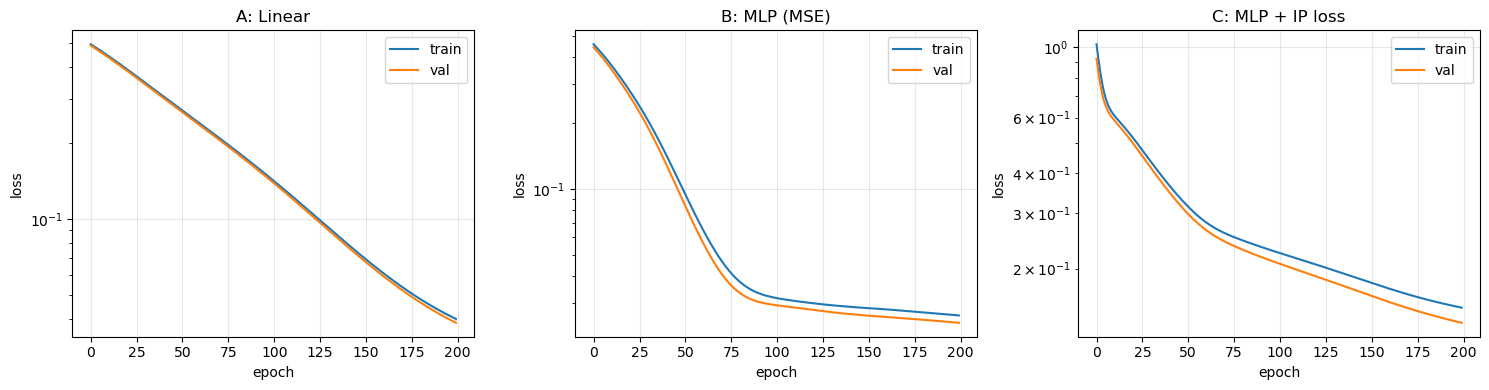

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, hist) in zip(axes, [
    ("A: Linear", hist_a),
    ("B: MLP (MSE)", hist_b),
    ("C: MLP + IP loss", hist_c),
]):
    ax.plot(hist["train"], label="train")
    ax.plot(hist["val"],   label="val")
    ax.set_title(name)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

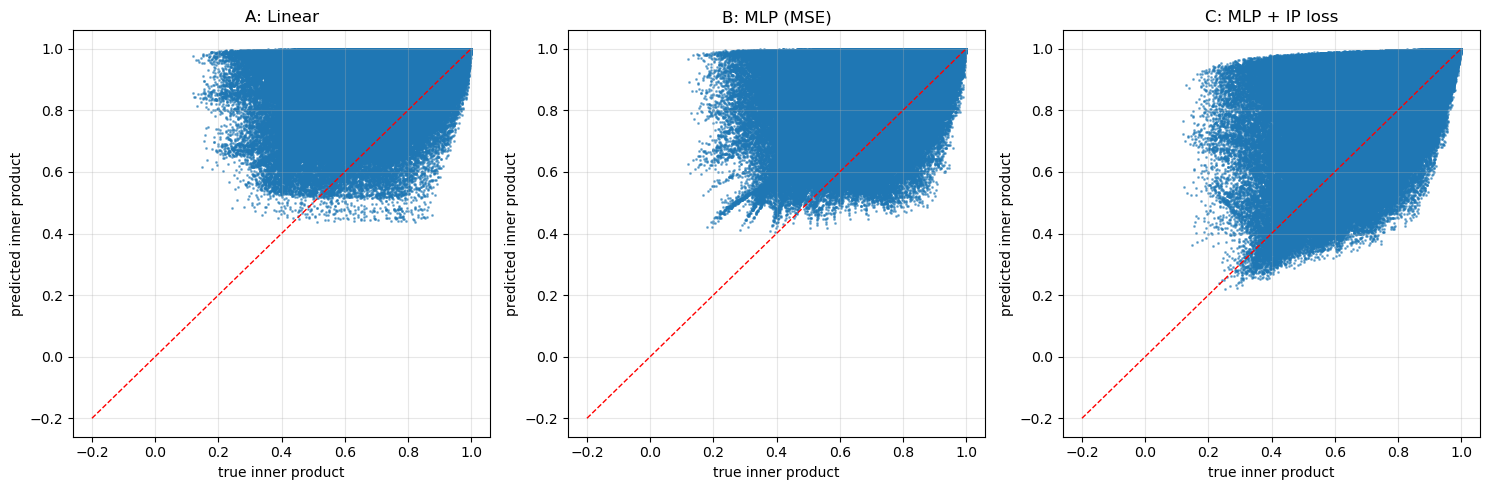

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, model) in zip(axes, [
    ("A: Linear", model_a),
    ("B: MLP (MSE)", model_b),
    ("C: MLP + IP loss", model_c),
]):
    model.eval()
    with torch.no_grad():
        psi_pred = model(z_test.to(DEVICE)).cpu()

    G_pred = psi_pred @ psi_pred.T
    G_true = psi_test @ psi_test.T

    # sample 1000 random pairs (avoid the diagonal)
    idx = torch.randperm(len(psi_test))[:1000]
    x = G_true[idx][:, idx].flatten().numpy()
    y = G_pred[idx][:, idx].flatten().numpy()

    ax.scatter(x, y, s=1, alpha=0.3)
    ax.plot([-0.2, 1.0], [-0.2, 1.0], "r--", linewidth=1)
    ax.set_xlabel("true inner product")
    ax.set_ylabel("predicted inner product")
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("inner_product_preservation.png", dpi=120, bbox_inches="tight")
plt.show()

In [16]:
# Cell 16 — Level 1 upgrade: 3-qubit Hilbert target (8 amplitudes)

N_QUBITS = 3
N_COMPONENTS = N_QUBITS          # 3 PCA directions
N_AMPLITUDES = 2 ** N_QUBITS     # 8 amplitudes

def fit_pca_n(z, n_components):
    """Fit PCA on training latents → top-n principal directions."""
    z_centered = z - z.mean(dim=0, keepdim=True)
    U, S, V = torch.svd(z_centered)
    components = V[:, :n_components]                        # (8, n)
    return components, z.mean(dim=0, keepdim=True)


def encode_to_psi_3q(z, components, mean):
    """
    Map z ∈ R^N×8 to ψ ∈ R^N×8 via PCA + 3-angle Ry encoding.

    |ψ⟩ = Ry(θ1) ⊗ Ry(θ2) ⊗ Ry(θ3) |000⟩

    Amplitude of basis state |b1 b2 b3⟩ is
        ∏_i  [ cos(θ_i/2) if b_i = 0 else sin(θ_i/2) ]

    Order of basis states follows tensor-product convention:
        index = b1 * 4 + b2 * 2 + b3
    """
    z_centered = z - mean
    proj = z_centered @ components                          # (N, 3)
    std = proj.std(dim=0, keepdim=True) + 1e-6
    proj = proj / std
    theta = torch.sigmoid(proj) * math.pi                   # (N, 3), in (0, π)

    # cos/sin halves
    c = torch.cos(theta / 2)                                # (N, 3)
    s = torch.sin(theta / 2)                                # (N, 3)

    # Build the 8 amplitudes
    # index = b1*4 + b2*2 + b3
    # amplitude[b] = prod_i ( c_i if b_i=0 else s_i )
    amps = []
    for b1 in (0, 1):
        for b2 in (0, 1):
            for b3 in (0, 1):
                a = (s[:, 0:1] if b1 else c[:, 0:1]) * \
                    (s[:, 1:2] if b2 else c[:, 1:2]) * \
                    (s[:, 2:3] if b3 else c[:, 2:3])
                amps.append(a)                              # each (N, 1)
    psi = torch.cat(amps, dim=1)                            # (N, 8)

    # safe normalize
    psi = psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)
    return psi


# Fit PCA on TRAIN latents only
components3, mean3 = fit_pca_n(z_train, N_COMPONENTS)
psi_train3 = encode_to_psi_3q(z_train, components3, mean3)
psi_test3  = encode_to_psi_3q(z_test,  components3, mean3)

print(f"3-qubit setup")
print(f"  components:   {components3.shape}")
print(f"  psi_train:    {psi_train3.shape}")
print(f"  psi_test:     {psi_test3.shape}")
print(f"  norm check:   {psi_train3.norm(dim=1).mean().item():.6f}  (should be ~1)")
print(f"  example:      {psi_train3[0].tolist()}")

3-qubit setup
  components:   torch.Size([8, 3])
  psi_train:    torch.Size([5000, 8])
  psi_test:     torch.Size([1000, 8])
  norm check:   1.000000  (should be ~1)
  example:      [0.5110424160957336, 0.19377537071704865, 0.4806723892688751, 0.18225976824760437, 0.45025965571403503, 0.17072798311710358, 0.4235018491744995, 0.160582035779953]


In [17]:
# Cell 17 — Models for 3-qubit target

class LinearModel3q(nn.Module):
    def __init__(self, in_dim=8, out_dim=8):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim)

    def forward(self, z):
        psi = self.fc(z)
        return psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)


class TinyMLP3q(nn.Module):
    def __init__(self, in_dim=8, hidden=32, out_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, z):
        psi = self.net(z)
        return psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)


print(f"Linear3q:  {count_params(LinearModel3q())} parameters")
print(f"TinyMLP3q: {count_params(TinyMLP3q())} parameters")

Linear3q:  72 parameters
TinyMLP3q: 552 parameters


In [18]:
# Cell 18 — Run all three models on 3-qubit target

# Train/val split for the mapping
n_val = 500
z3_train, psi3_train = z_train[:-n_val], psi_train3[:-n_val]
z3_val,   psi3_val   = z_train[-n_val:], psi_train3[-n_val:]

results3 = {}

# ---- A. Linear ----
print("=" * 60)
print("  Model A: Linear (3-qubit target)")
print("=" * 60)
t0 = time.time()
model_a3, hist_a3 = train_model(
    LinearModel3q(), z3_train, psi3_train, z3_val, psi3_val,
    epochs=200, lr=1e-3, w_mse=1.0, w_ip=0.0, w_dist=0.0, verbose=True,
)
results3["A_linear"] = evaluate(model_a3, z_test, psi_test3)
print(f"  time: {time.time()-t0:.1f}s   test: {results3['A_linear']}")

# ---- B. MLP (MSE only) ----
print()
print("=" * 60)
print("  Model B: Tiny MLP (MSE only) — 3-qubit target")
print("=" * 60)
t0 = time.time()
model_b3, hist_b3 = train_model(
    TinyMLP3q(), z3_train, psi3_train, z3_val, psi3_val,
    epochs=200, lr=1e-3, w_mse=1.0, w_ip=0.0, w_dist=0.0, verbose=True,
)
results3["B_mlp_mse"] = evaluate(model_b3, z_test, psi_test3)
print(f"  time: {time.time()-t0:.1f}s   test: {results3['B_mlp_mse']}")

# ---- C. MLP + inner-product loss ----
print()
print("=" * 60)
print("  Model C: Tiny MLP (MSE + IP loss) — 3-qubit target")
print("=" * 60)
t0 = time.time()
model_c3, hist_c3 = train_model(
    TinyMLP3q(), z3_train, psi3_train, z3_val, psi3_val,
    epochs=200, lr=1e-3, w_mse=1.0, w_ip=5.0, w_dist=0.0, verbose=True,
)
results3["C_mlp_mse_ip"] = evaluate(model_c3, z_test, psi_test3)
print(f"  time: {time.time()-t0:.1f}s   test: {results3['C_mlp_mse_ip']}")

print()
print(f"✓ Trained 3 models (3-qubit). Results dict has {len(results3)} keys.")

  Model A: Linear (3-qubit target)
  epoch  25  train=0.216628  val=0.215448
  epoch  50  train=0.164921  val=0.163827
  epoch  75  train=0.126288  val=0.125445
  epoch 100  train=0.098905  val=0.098236
  epoch 125  train=0.078833  val=0.078252
  epoch 150  train=0.063494  val=0.062958
  epoch 175  train=0.051582  val=0.051079
  epoch 200  train=0.042498  val=0.042031
  time: 87.1s   test: {'mse': 0.04154018312692642, 'cosine': 0.8338392972946167, 'ip_err': 0.22016975283622742, 'dist_err': 0.4396539330482483}

  Model B: Tiny MLP (MSE only) — 3-qubit target
  epoch  25  train=0.052492  val=0.049881
  epoch  50  train=0.027452  val=0.026713
  epoch  75  train=0.024119  val=0.023284
  epoch 100  train=0.021919  val=0.021232
  epoch 125  train=0.019942  val=0.019251
  epoch 150  train=0.018068  val=0.017450
  epoch 175  train=0.015990  val=0.015493
  epoch 200  train=0.013180  val=0.012692
  time: 87.2s   test: {'mse': 0.013984101824462414, 'cosine': 0.9440637230873108, 'ip_err': 0.126125

In [19]:
# Cell 19 — Summary table (3-qubit)

print()
print("=" * 78)
print(f"{'model':<22} {'MSE':>10} {'cosine':>10} {'IP_err':>10} {'dist_err':>10}")
print("=" * 78)
for name, r in results3.items():
    print(f"{name:<22} {r['mse']:>10.6f} {r['cosine']:>10.4f} "
          f"{r['ip_err']:>10.4f} {r['dist_err']:>10.4f}")
print("=" * 78)

# Random baseline
with torch.no_grad():
    rand_pred = torch.randn_like(psi_test3)
    rand_pred = rand_pred / rand_pred.norm(dim=1, keepdim=True)

G_pred = rand_pred @ rand_pred.T
G_true = psi_test3 @ psi_test3.T
rand_ip_err = (G_pred - G_true).abs().mean().item()
d_pred = torch.cdist(rand_pred, rand_pred)
d_true = torch.cdist(psi_test3, psi_test3)
rand_dist_err = (d_pred - d_true).abs().mean().item()
print(f"{'random baseline':<22} {'':>10} {'':>10} {rand_ip_err:>10.4f} {rand_dist_err:>10.4f}")
print("=" * 78)

# ---- Compare 2-qubit vs 3-qubit ----
print()
print("Side-by-side comparison (2-qubit vs 3-qubit):")
print(f"{'model':<22} {'2q IP_err':>12} {'3q IP_err':>12} {'Δ':>10}")
print("-" * 60)
for (name2, r2), (name3, r3) in zip(results.items(), results3.items()):
    delta = r3["ip_err"] - r2["ip_err"]
    print(f"{name2:<22} {r2['ip_err']:>12.4f} {r3['ip_err']:>12.4f} {delta:>+10.4f}")


model                         MSE     cosine     IP_err   dist_err
A_linear                 0.041540     0.8338     0.2202     0.4397
B_mlp_mse                0.013984     0.9441     0.1261     0.2117
C_mlp_mse_ip             0.036576     0.8537     0.0462     0.0710
random baseline                                  0.7449     0.7238

Side-by-side comparison (2-qubit vs 3-qubit):
model                     2q IP_err    3q IP_err          Δ
------------------------------------------------------------
A_linear_mse                 0.1324       0.2202    +0.0877
B_mlp_mse                    0.1122       0.1261    +0.0139
C_mlp_mse_ip                 0.0919       0.0462    -0.0457


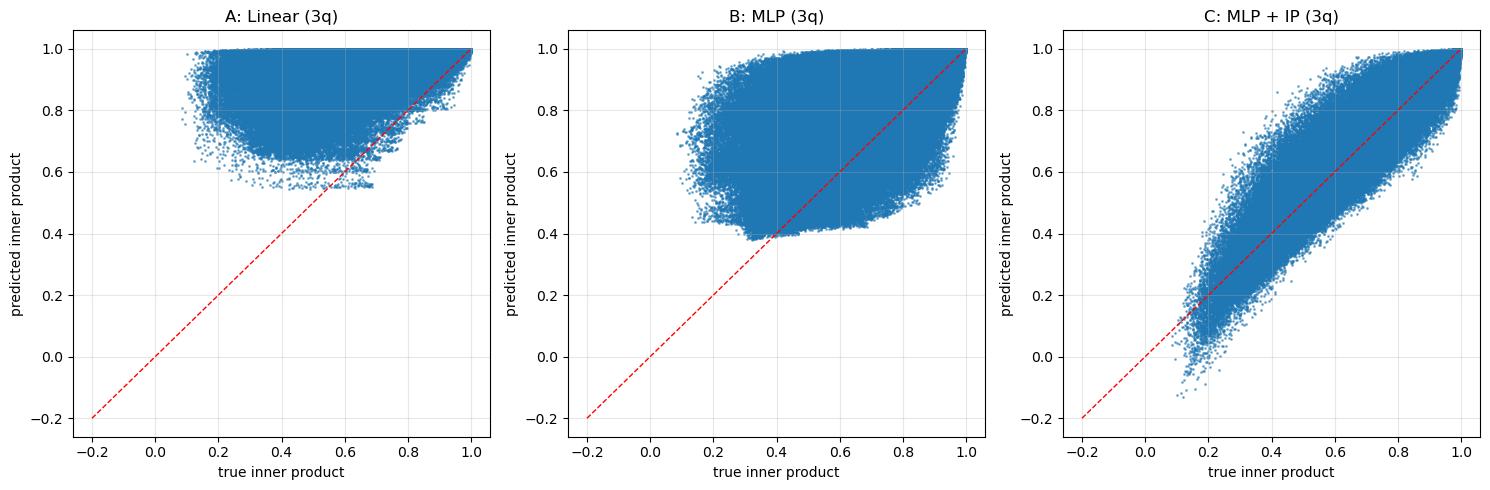

In [20]:
# Cell 20 — Inner-product preservation scatter (3-qubit)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, model) in zip(axes, [
    ("A: Linear (3q)", model_a3),
    ("B: MLP (3q)", model_b3),
    ("C: MLP + IP (3q)", model_c3),
]):
    model.eval()
    with torch.no_grad():
        psi_pred = model(z_test.to(DEVICE)).cpu()

    G_pred = psi_pred @ psi_pred.T
    G_true = psi_test3 @ psi_test3.T

    idx = torch.randperm(len(psi_test3))[:1000]
    x = G_true[idx][:, idx].flatten().numpy()
    y = G_pred[idx][:, idx].flatten().numpy()

    ax.scatter(x, y, s=1, alpha=0.3)
    ax.plot([-0.2, 1.0], [-0.2, 1.0], "r--", linewidth=1)
    ax.set_xlabel("true inner product")
    ax.set_ylabel("predicted inner product")
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("inner_product_preservation_3q.png", dpi=120, bbox_inches="tight")
plt.show()

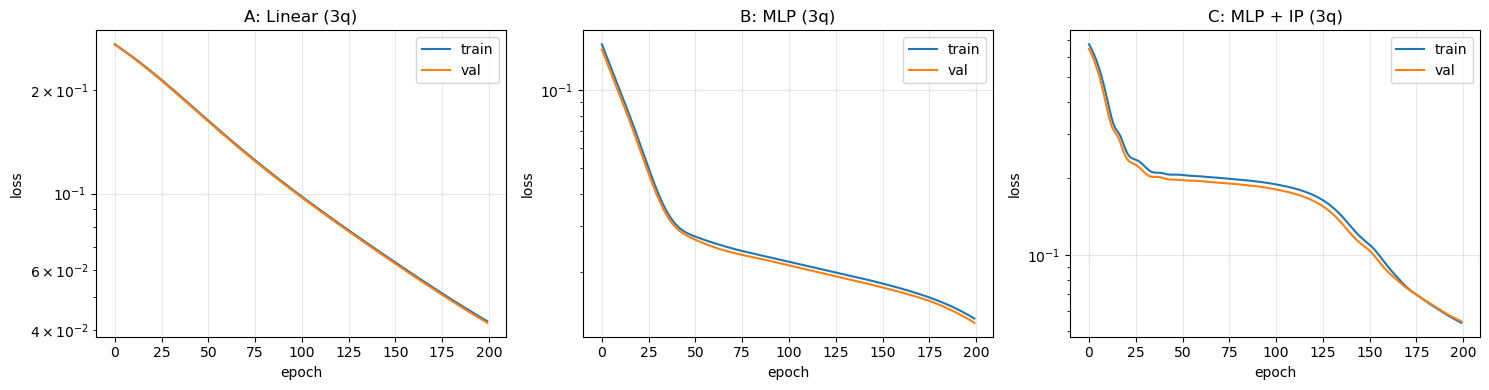

In [21]:
# Cell 21 — Training curves (3-qubit)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, hist) in zip(axes, [
    ("A: Linear (3q)", hist_a3),
    ("B: MLP (3q)", hist_b3),
    ("C: MLP + IP (3q)", hist_c3),
]):
    ax.plot(hist["train"], label="train")
    ax.plot(hist["val"],   label="val")
    ax.set_title(name)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves_3q.png", dpi=120, bbox_inches="tight")
plt.show()

In [22]:
# Cell 22 — Interpret the 3-qubit result

print("=" * 78)
print("  INTERPRETATION")
print("=" * 78)

# Extract key numbers
ip_2q_linear = results["A_linear_mse"]["ip_err"]
ip_2q_mlp    = results["B_mlp_mse"]["ip_err"]
ip_2q_ip     = results["C_mlp_mse_ip"]["ip_err"]

ip_3q_linear = results3["A_linear"]["ip_err"]
ip_3q_mlp    = results3["B_mlp_mse"]["ip_err"]
ip_3q_ip     = results3["C_mlp_mse_ip"]["ip_err"]

print(f"2-qubit IP_err → 3-qubit IP_err")
print(f"  Linear:  {ip_2q_linear:.4f} → {ip_3q_linear:.4f}  "
      f"(Δ = {ip_3q_linear - ip_2q_linear:+.4f})")
print(f"  MLP:     {ip_2q_mlp:.4f} → {ip_3q_mlp:.4f}  "
      f"(Δ = {ip_3q_mlp - ip_2q_mlp:+.4f})")
print(f"  MLP+IP:  {ip_2q_ip:.4f} → {ip_3q_ip:.4f}  "
      f"(Δ = {ip_3q_ip - ip_2q_ip:+.4f})")
print()

# Decision rules
if ip_3q_ip < ip_2q_ip:
    print("✓ IP preservation got BETTER with more qubits.")
    print("  → This is unexpected and interesting. Scale further.")
elif ip_3q_ip < ip_2q_ip * 1.3:
    print("✓ IP preservation held up with more qubits (within 30%).")
    print("  → The relationship is stable. Scale to 4 qubits or a VAE.")
else:
    print("⚠ IP preservation degraded significantly with more qubits.")
    print("  → The 2-qubit result may be specific to small targets.")
    print("  → Try a different ψ encoding, or add more training data.")

print()
print("Next options:")
print("  Level 2 — replace TinyAE with a VAE (1 hour)")
print("  Level 3 — replace TinyAE with a real DDPM (3 hours)")
print("  Level 4 — replace classical Ry with a PennyLane circuit (2 hours)")
print("  Publish — write up the current result as a blog post (2 hours)")

  INTERPRETATION
2-qubit IP_err → 3-qubit IP_err
  Linear:  0.1324 → 0.2202  (Δ = +0.0877)
  MLP:     0.1122 → 0.1261  (Δ = +0.0139)
  MLP+IP:  0.0919 → 0.0462  (Δ = -0.0457)

✓ IP preservation got BETTER with more qubits.
  → This is unexpected and interesting. Scale further.

Next options:
  Level 2 — replace TinyAE with a VAE (1 hour)
  Level 3 — replace TinyAE with a real DDPM (3 hours)
  Level 4 — replace classical Ry with a PennyLane circuit (2 hours)
  Publish — write up the current result as a blog post (2 hours)


In [23]:
# Cell 23 — 4-qubit setup
N_QUBITS = 4
N_COMPONENTS = 4
N_AMPLITUDES = 16

def encode_to_psi_4q(z, components, mean):
    """
    Map z ∈ R^N×8 → ψ ∈ R^N×16 via PCA + 4-angle Ry encoding.

    |ψ⟩ = Ry(θ1) ⊗ Ry(θ2) ⊗ Ry(θ3) ⊗ Ry(θ4) |0000⟩

    Basis index: b1*8 + b2*4 + b3*2 + b4
    """
    z_centered = z - mean
    proj = z_centered @ components
    std = proj.std(dim=0, keepdim=True) + 1e-6
    proj = proj / std
    theta = torch.sigmoid(proj) * math.pi              # (N, 4)

    c = torch.cos(theta / 2)
    s = torch.sin(theta / 2)

    amps = []
    for b1 in (0, 1):
        for b2 in (0, 1):
            for b3 in (0, 1):
                for b4 in (0, 1):
                    a = (s[:, 0:1] if b1 else c[:, 0:1]) * \
                        (s[:, 1:2] if b2 else c[:, 1:2]) * \
                        (s[:, 2:3] if b3 else c[:, 2:3]) * \
                        (s[:, 3:4] if b4 else c[:, 3:4])
                    amps.append(a)
    psi = torch.cat(amps, dim=1)                       # (N, 16)
    psi = psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)
    return psi


components4, mean4 = fit_pca_n(z_train, N_COMPONENTS)
psi_train4 = encode_to_psi_4q(z_train, components4, mean4)
psi_test4  = encode_to_psi_4q(z_test,  components4, mean4)

print(f"psi_train4: {psi_train4.shape}")
print(f"psi_test4:  {psi_test4.shape}")

psi_train4: torch.Size([5000, 16])
psi_test4:  torch.Size([1000, 16])


In [24]:
# Cell 24 — models for 4-qubit
class LinearModel4q(nn.Module):
    def __init__(self, in_dim=8, out_dim=16):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim)
    def forward(self, z):
        psi = self.fc(z)
        return psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)


class TinyMLP4q(nn.Module):
    def __init__(self, in_dim=8, hidden=32, out_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, z):
        psi = self.net(z)
        return psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)

In [25]:
# Cell 25 — train the three models on 4-qubit target

n_val = 500
z4_train, psi4_train = z_train[:-n_val], psi_train4[:-n_val]
z4_val,   psi4_val   = z_train[-n_val:], psi_train4[-n_val:]

results4 = {}

print("Model A: Linear (4q)")
model_a4, _ = train_model(LinearModel4q(), z4_train, psi4_train,
                          z4_val, psi4_val, epochs=200, lr=1e-3,
                          w_mse=1.0, w_ip=0.0, verbose=True)
results4["A_linear"] = evaluate(model_a4, z_test, psi_test4)

print("\nModel B: MLP (MSE only) — 4q")
model_b4, _ = train_model(TinyMLP4q(), z4_train, psi4_train,
                          z4_val, psi4_val, epochs=200, lr=1e-3,
                          w_mse=1.0, w_ip=0.0, verbose=True)
results4["B_mlp_mse"] = evaluate(model_b4, z_test, psi_test4)

print("\nModel C: MLP + IP loss — 4q")
model_c4, _ = train_model(TinyMLP4q(), z4_train, psi_train4 if False else psi4_train,
                          z4_val, psi4_val, epochs=200, lr=1e-3,
                          w_mse=1.0, w_ip=5.0, verbose=True)
results4["C_mlp_mse_ip"] = evaluate(model_c4, z_test, psi_test4)

Model A: Linear (4q)
  epoch  25  train=0.114344  val=0.114367
  epoch  50  train=0.085240  val=0.085277
  epoch  75  train=0.063631  val=0.063669
  epoch 100  train=0.048445  val=0.048393
  epoch 125  train=0.037755  val=0.037577
  epoch 150  train=0.030460  val=0.030159
  epoch 175  train=0.025718  val=0.025312
  epoch 200  train=0.022728  val=0.022240

Model B: MLP (MSE only) — 4q
  epoch  25  train=0.049727  val=0.047924
  epoch  50  train=0.027980  val=0.027126
  epoch  75  train=0.021979  val=0.021256
  epoch 100  train=0.019570  val=0.018858
  epoch 125  train=0.017771  val=0.017064
  epoch 150  train=0.016398  val=0.015712
  epoch 175  train=0.015454  val=0.014766
  epoch 200  train=0.014653  val=0.013930

Model C: MLP + IP loss — 4q
  epoch  25  train=0.415344  val=0.388845
  epoch  50  train=0.365914  val=0.342368
  epoch  75  train=0.346134  val=0.322380
  epoch 100  train=0.328693  val=0.304695
  epoch 125  train=0.299645  val=0.275764
  epoch 150  train=0.224928  val=0.203

In [26]:
# Cell 26 — combined 2q / 3q / 4q comparison

print(f"{'model':<20} {'2q IP_err':>12} {'3q IP_err':>12} {'4q IP_err':>12}")
print("-" * 60)
for k2, k3, k4 in zip(results.keys(), results3.keys(), results4.keys()):
    print(f"{k2:<20} {results[k2]['ip_err']:>12.4f} "
          f"{results3[k3]['ip_err']:>12.4f} "
          f"{results4[k4]['ip_err']:>12.4f}")

print()
print(f"{'model':<20} {'2q MSE':>12} {'3q MSE':>12} {'4q MSE':>12}")
print("-" * 60)
for k2, k3, k4 in zip(results.keys(), results3.keys(), results4.keys()):
    print(f"{k2:<20} {results[k2]['mse']:>12.4f} "
          f"{results3[k3]['mse']:>12.4f} "
          f"{results4[k4]['mse']:>12.4f}")

model                   2q IP_err    3q IP_err    4q IP_err
------------------------------------------------------------
A_linear_mse               0.1324       0.2202       0.2830
B_mlp_mse                  0.1122       0.1261       0.2156
C_mlp_mse_ip               0.0919       0.0462       0.0998

model                      2q MSE       3q MSE       4q MSE
------------------------------------------------------------
A_linear_mse               0.0436       0.0415       0.0224
B_mlp_mse                  0.0290       0.0140       0.0152
C_mlp_mse_ip               0.0652       0.0366       0.0358


In [27]:
# Cell 26 — combined 2q / 3q / 4q comparison

print(f"{'model':<20} {'2q IP_err':>12} {'3q IP_err':>12} {'4q IP_err':>12}")
print("-" * 60)
for k2, k3, k4 in zip(results.keys(), results3.keys(), results4.keys()):
    print(f"{k2:<20} {results[k2]['ip_err']:>12.4f} "
          f"{results3[k3]['ip_err']:>12.4f} "
          f"{results4[k4]['ip_err']:>12.4f}")

print()
print(f"{'model':<20} {'2q MSE':>12} {'3q MSE':>12} {'4q MSE':>12}")
print("-" * 60)
for k2, k3, k4 in zip(results.keys(), results3.keys(), results4.keys()):
    print(f"{k2:<20} {results[k2]['mse']:>12.4f} "
          f"{results3[k3]['mse']:>12.4f} "
          f"{results4[k4]['mse']:>12.4f}")

model                   2q IP_err    3q IP_err    4q IP_err
------------------------------------------------------------
A_linear_mse               0.1324       0.2202       0.2830
B_mlp_mse                  0.1122       0.1261       0.2156
C_mlp_mse_ip               0.0919       0.0462       0.0998

model                      2q MSE       3q MSE       4q MSE
------------------------------------------------------------
A_linear_mse               0.0436       0.0415       0.0224
B_mlp_mse                  0.0290       0.0140       0.0152
C_mlp_mse_ip               0.0652       0.0366       0.0358


In [28]:
# Cell 27 — retrain 4q Model C with more epochs

# Reduce IP weight to help optimization
print("Model C (4q) — 1000 epochs, IP weight 1.0")
model_c4_long, hist_c4_long = train_model(
    TinyMLP4q(), z4_train, psi4_train, z4_val, psi4_val,
    epochs=1000, lr=1e-3,
    w_mse=1.0, w_ip=1.0, w_dist=0.0,
    verbose=False,   # turn off intermediate prints
)

results4_long = evaluate(model_c4_long, z_test, psi_test4)

print(f"\nAfter 1000 epochs (IP weight 1.0):")
print(f"  MSE:      {results4_long['mse']:.4f}")
print(f"  IP_err:   {results4_long['ip_err']:.4f}")
print(f"  dist_err: {results4_long['dist_err']:.4f}")

Model C (4q) — 1000 epochs, IP weight 1.0

After 1000 epochs (IP weight 1.0):
  MSE:      0.0025
  IP_err:   0.0266
  dist_err: 0.0351


In [29]:
# Cell 28 — variance check: 3 seeds × 3 qubit counts

def run_experiment(n_qubits, seed, epochs=500, ip_weight=1.0):
    """Run one full experiment with a given seed."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Build target for this qubit count
    if n_qubits == 2:
        comps, m = fit_pca_n(z_train, 2)
        psi_tr = encode_to_psi(z_train, comps, m)
        psi_te = encode_to_psi(z_test,  comps, m)
        Model = TinyMLP
    elif n_qubits == 3:
        comps, m = fit_pca_n(z_train, 3)
        psi_tr = encode_to_psi_3q(z_train, comps, m)
        psi_te = encode_to_psi_3q(z_test,  comps, m)
        Model = TinyMLP3q
    elif n_qubits == 4:
        comps, m = fit_pca_n(z_train, 4)
        psi_tr = encode_to_psi_4q(z_train, comps, m)
        psi_te = encode_to_psi_4q(z_test,  comps, m)
        Model = TinyMLP4q

    n_val = 500
    z_tr, psi_tr_ = z_train[:-n_val], psi_tr[:-n_val]
    z_va, psi_va_ = z_train[-n_val:], psi_tr[-n_val:]

    model, _ = train_model(Model(), z_tr, psi_tr_, z_va, psi_va_,
                           epochs=epochs, lr=1e-3,
                           w_mse=1.0, w_ip=ip_weight, verbose=False)
    return evaluate(model, z_test, psi_te)


# Run: 3 qubit counts × 3 seeds
print("Variance check (3 seeds × 3 qubit counts):")
print(f"{'nq':>4} {'seed':>6} {'MSE':>10} {'IP_err':>10} {'dist_err':>10}")
print("-" * 45)

all_results = {2: [], 3: [], 4: []}
for nq in (2, 3, 4):
    for seed in (42, 123, 7):
        r = run_experiment(nq, seed, epochs=500, ip_weight=1.0)
        all_results[nq].append(r)
        print(f"{nq:>4} {seed:>6} {r['mse']:>10.4f} {r['ip_err']:>10.4f} {r['dist_err']:>10.4f}")

print()
print("Mean ± std across seeds:")
print(f"{'nq':>4} {'mean IP_err':>14} {'std IP_err':>12} {'mean MSE':>12}")
for nq in (2, 3, 4):
    ip_errs = [r['ip_err'] for r in all_results[nq]]
    mses    = [r['mse'] for r in all_results[nq]]
    print(f"{nq:>4} {np.mean(ip_errs):>14.4f} {np.std(ip_errs):>12.4f} {np.mean(mses):>12.4f}")

Variance check (3 seeds × 3 qubit counts):
  nq   seed        MSE     IP_err   dist_err
---------------------------------------------
   2     42     0.0118     0.0817     0.1408
   2    123     0.0197     0.0969     0.1756
   2      7     0.0020     0.0177     0.0310
   3     42     0.0027     0.0210     0.0319
   3    123     0.0030     0.0212     0.0321
   3      7     0.0048     0.0314     0.0480
   4     42     0.0040     0.0308     0.0409
   4    123     0.0038     0.0327     0.0441
   4      7     0.0037     0.0316     0.0421

Mean ± std across seeds:
  nq    mean IP_err   std IP_err     mean MSE
   2         0.0654       0.0343       0.0111
   3         0.0245       0.0049       0.0035
   4         0.0317       0.0008       0.0038


In [30]:
# Cell 29 — 5-qubit setup
N_QUBITS = 5
N_COMPONENTS = 5
N_AMPLITUDES = 32

def encode_to_psi_5q(z, components, mean):
    z_centered = z - mean
    proj = z_centered @ components
    std = proj.std(dim=0, keepdim=True) + 1e-6
    proj = proj / std
    theta = torch.sigmoid(proj) * math.pi             # (N, 5)
    c = torch.cos(theta / 2)
    s = torch.sin(theta / 2)

    amps = []
    for b1 in (0, 1):
        for b2 in (0, 1):
            for b3 in (0, 1):
                for b4 in (0, 1):
                    for b5 in (0, 1):
                        a = (s[:, 0:1] if b1 else c[:, 0:1]) * \
                            (s[:, 1:2] if b2 else c[:, 1:2]) * \
                            (s[:, 2:3] if b3 else c[:, 2:3]) * \
                            (s[:, 3:4] if b4 else c[:, 3:4]) * \
                            (s[:, 4:5] if b5 else c[:, 4:5])
                        amps.append(a)
    psi = torch.cat(amps, dim=1)
    return psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)


components5, mean5 = fit_pca_n(z_train, 5)
psi_train5 = encode_to_psi_5q(z_train, components5, mean5)
psi_test5  = encode_to_psi_5q(z_test,  components5, mean5)

In [31]:
# Cell 30 — 5-qubit model
class TinyMLP5q(nn.Module):
    def __init__(self, in_dim=8, hidden=64, out_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, z):
        psi = self.net(z)
        return psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)

In [32]:
# Cell 31 — train 5q model C, 3 seeds
print(f"{'nq':>4} {'seed':>6} {'MSE':>10} {'IP_err':>10}")
print("-" * 35)
for seed in (42, 123, 7):
    torch.manual_seed(seed)
    np.random.seed(seed)

    n_val = 500
    z_tr, psi_tr_ = z_train[:-n_val], psi_train5[:-n_val]
    z_va, psi_va_ = z_train[-n_val:], psi_train5[-n_val:]

    model, _ = train_model(TinyMLP5q(), z_tr, psi_tr_, z_va, psi_va_,
                           epochs=500, lr=1e-3,
                           w_mse=1.0, w_ip=1.0, verbose=False)
    r = evaluate(model, z_test, psi_test5)
    print(f"{5:>4} {seed:>6} {r['mse']:>10.4f} {r['ip_err']:>10.4f}")

  nq   seed        MSE     IP_err
-----------------------------------
   5     42     0.0069     0.0523
   5    123     0.0068     0.0450
   5      7     0.0075     0.0437


In [33]:
# Cell 32 — baseline comparison: B vs C across seeds

print("Model B (MSE only) vs Model C (MSE + IP) — 3 and 4 qubits, 3 seeds")
print(f"{'nq':>4} {'seed':>6} {'B IP_err':>10} {'C IP_err':>10} {'C/B':>8}")
print("-" * 45)

for nq in (3, 4):
    if nq == 3:
        comps, m = fit_pca_n(z_train, 3)
        psi_tr = encode_to_psi_3q(z_train, comps, m)
        psi_te = encode_to_psi_3q(z_test,  comps, m)
        Model = TinyMLP3q
    else:
        comps, m = fit_pca_n(z_train, 4)
        psi_tr = encode_to_psi_4q(z_train, comps, m)
        psi_te = encode_to_psi_4q(z_test,  comps, m)
        Model = TinyMLP4q

    for seed in (42, 123, 7):
        torch.manual_seed(seed)
        np.random.seed(seed)

        n_val = 500
        z_tr, psi_tr_ = z_train[:-n_val], psi_tr[:-n_val]
        z_va, psi_va_ = z_train[-n_val:], psi_tr[-n_val:]

        mB, _ = train_model(Model(), z_tr, psi_tr_, z_va, psi_va_,
                            epochs=500, lr=1e-3,
                            w_mse=1.0, w_ip=0.0, verbose=False)
        mC, _ = train_model(Model(), z_tr, psi_tr_, z_va, psi_va_,
                            epochs=500, lr=1e-3,
                            w_mse=1.0, w_ip=1.0, verbose=False)

        rB = evaluate(mB, z_test, psi_te)
        rC = evaluate(mC, z_test, psi_te)
        ratio = rC['ip_err'] / rB['ip_err']

        print(f"{nq:>4} {seed:>6} {rB['ip_err']:>10.4f} {rC['ip_err']:>10.4f} {ratio:>8.2f}x")

Model B (MSE only) vs Model C (MSE + IP) — 3 and 4 qubits, 3 seeds
  nq   seed   B IP_err   C IP_err      C/B
---------------------------------------------
   3     42     0.0315     0.0238     0.75x
   3    123     0.0307     0.0197     0.64x
   3      7     0.0522     0.0386     0.74x
   4     42     0.0696     0.0309     0.44x
   4    123     0.0579     0.0330     0.57x
   4      7     0.0918     0.0332     0.36x
